In [1]:
# ==========================================
# CodeAlpha Internship
# Task 3 - Data Visualization
# Author: Muhammad Abdur Rehman
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================
# Load Dataset
# ==========================================

import pandas as pd

df = pd.read_csv("../dataset/Sample - Superstore.csv", encoding="latin-1")

print("✅ Dataset Loaded Successfully")
print()

print("Shape:", df.shape)
print()

df.head()

✅ Dataset Loaded Successfully

Shape: (9994, 21)



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# ==========================================
# Dataset Information
# ==========================================

print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
# ==========================================
# Summary Statistics
# ==========================================

df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


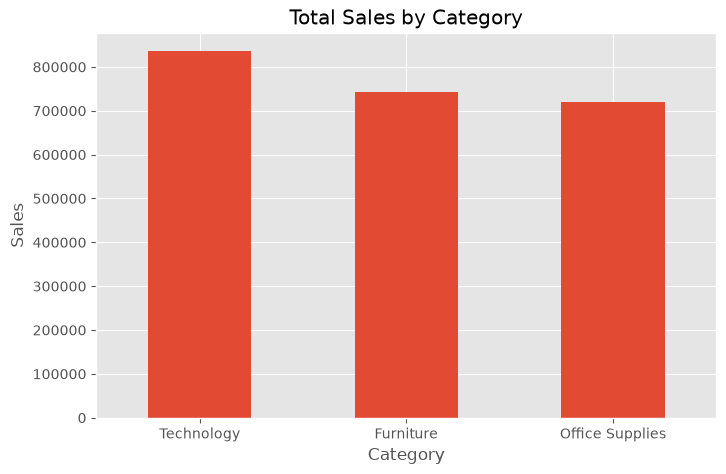

In [5]:
# ==========================================
# Sales by Category
# ==========================================

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

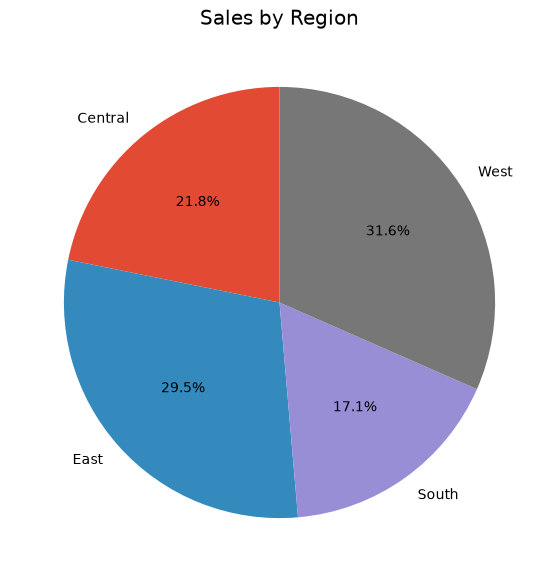

In [6]:
# ==========================================
# Sales by Region
# ==========================================

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(7,7))

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales by Region")

plt.show()

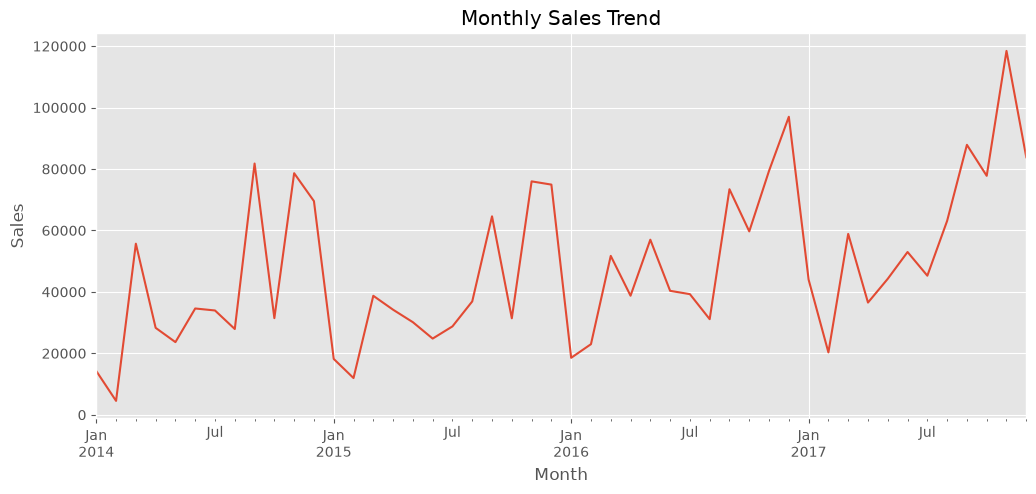

In [7]:
# ==========================================
# Monthly Sales
# ==========================================

df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

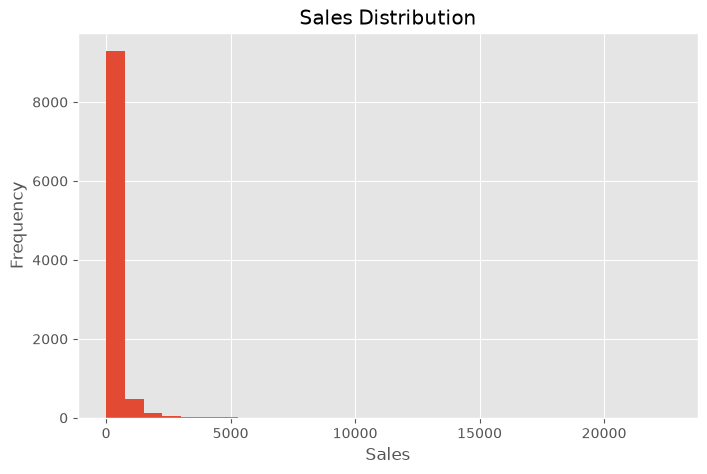

In [8]:
# ==========================================
# Sales Distribution
# ==========================================

plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")

plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

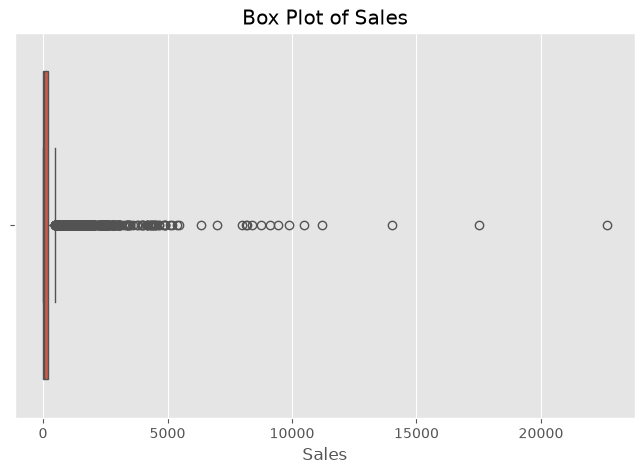

In [9]:
# ==========================================
# Box Plot
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Sales"])

plt.title("Box Plot of Sales")

plt.show()

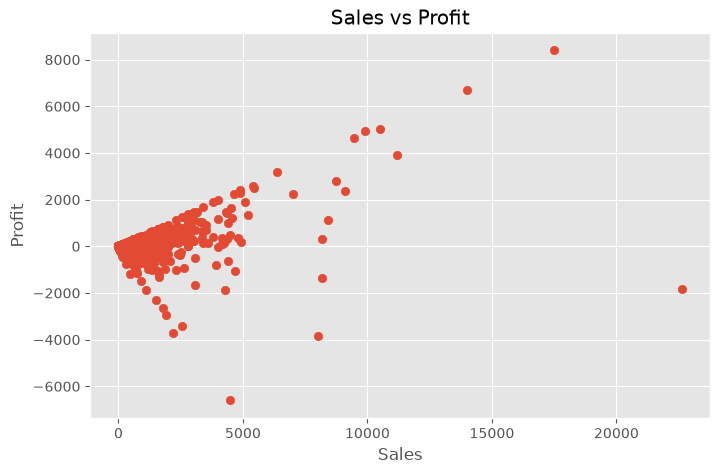

In [10]:
# ==========================================
# Scatter Plot
# ==========================================

plt.figure(figsize=(8,5))

plt.scatter(df["Sales"], df["Profit"])

plt.title("Sales vs Profit")

plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

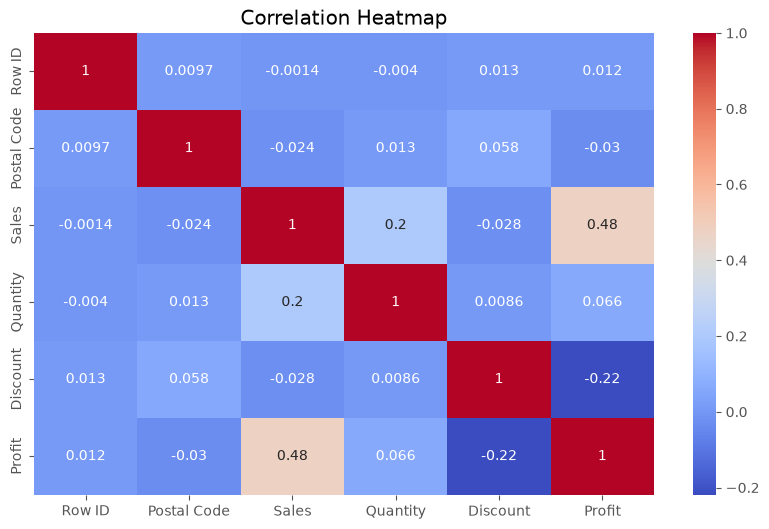

In [11]:
# ==========================================
# Correlation Heatmap
# ==========================================

numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

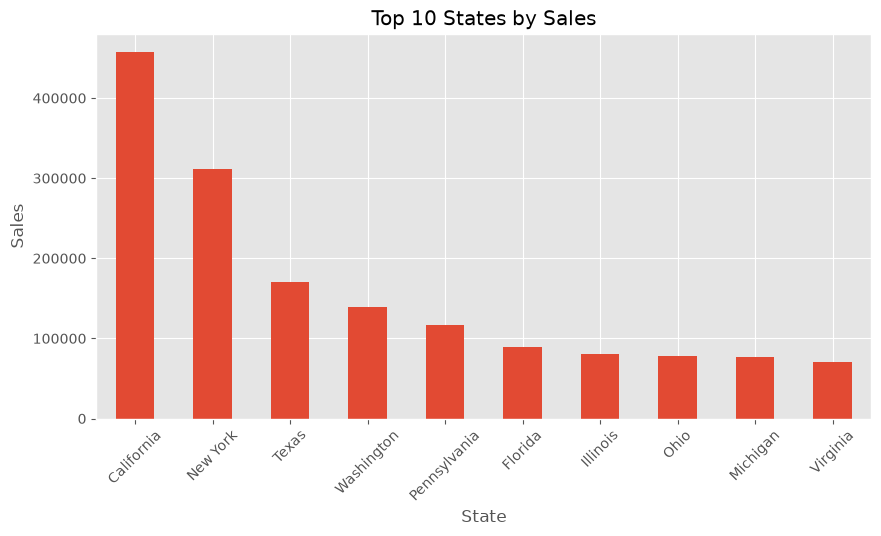

In [12]:
# ==========================================
# Top 10 States by Sales
# ==========================================

top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

top_states.plot(kind="bar")

plt.title("Top 10 States by Sales")

plt.xlabel("State")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [13]:
# ==========================================
# Conclusion
# ==========================================

print("=" * 50)
print("      Data Visualization Completed")
print("=" * 50)

print("\nProject Summary:")
print("- Dataset Loaded Successfully")
print("- Dataset Explored")
print("- Missing Values Checked")
print("- Summary Statistics Generated")
print("- Bar Chart Created")
print("- Pie Chart Created")
print("- Line Chart Created")
print("- Histogram Created")
print("- Box Plot Created")
print("- Scatter Plot Created")
print("- Correlation Heatmap Created")

print("\nCodeAlpha Data Visualization Project Completed Successfully!")

      Data Visualization Completed

Project Summary:
- Dataset Loaded Successfully
- Dataset Explored
- Missing Values Checked
- Summary Statistics Generated
- Bar Chart Created
- Pie Chart Created
- Line Chart Created
- Histogram Created
- Box Plot Created
- Scatter Plot Created
- Correlation Heatmap Created

CodeAlpha Data Visualization Project Completed Successfully!
